In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Large
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [6]:
# Data paths
train_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
img_size = (224, 224)
batch_size = 32

In [7]:
# Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 7200 images belonging to 9 classes.
Found 1800 images belonging to 9 classes.


In [ ]:
print(val_generator.class_indices)

In [ ]:
# Build model
base_model = MobileNetV3Large(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
predictions = Dense(train_generator.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# Compile
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
# Train
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


I0000 00:00:1776278418.931819    6635 generator_dataset_op.cc:213] Memory patch applied: M_TRIM_THRESHOLD=128 kb was set.
I0000 00:00:1776278423.639094    7321 service.cc:153] XLA service 0x7a25a0034020 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776278423.639136    7321 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.1.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.20.0)
I0000 00:00:1776278423.773654    7321 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776278424.941228    7321 cuda_dnn.cc:461] Loaded cuDNN version 92000
I0000 00:00:1776278424.982792    7321 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_9510__.169
E0000 00:00:1776278433.910599    7321 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, p

225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.1481 - loss: 2.1869

E0000 00:00:1776278527.961003    7320 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1776278531.056695    7320 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


225/225 ━━━━━━━━━━━━━━━━━━━━ 123s 436ms/step - accuracy: 0.1754 - loss: 2.1621 - val_accuracy: 0.1733 - val_loss: 2.1499
Epoch 2/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 68s 300ms/step - accuracy: 0.2482 - loss: 2.0873 - val_accuracy: 0.2339 - val_loss: 2.1131
Epoch 3/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 275ms/step - accuracy: 0.2761 - loss: 2.0315 - val_accuracy: 0.2222 - val_loss: 2.0851
Epoch 4/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 67s 296ms/step - accuracy: 0.2972 - loss: 1.9869 - val_accuracy: 0.2500 - val_loss: 2.0794
Epoch 5/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 270ms/step - accuracy: 0.3140 - loss: 1.9529 - val_accuracy: 0.2344 - val_loss: 2.0394
Epoch 6/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 61s 270ms/step - accuracy: 0.3281 - loss: 1.9210 - val_accuracy: 0.2489 - val_loss: 2.0290
Epoch 7/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 275ms/step - accuracy: 0.3363 - loss: 1.8940 - val_accuracy: 0.2350 - val_loss: 2.0155
Epoch 8/10
225/225 ━━━━━━━━━━━━━━━━━━━━ 64s 284ms/step - accuracy: 0.3539 - loss: 1.8696 - va

In [ ]:
# Save model
from pathlib import Path

project_root = Path('/home/groggy/projects/Image-Classification-Explainability')
save_path = project_root / 'ML' / 'Models' / 'MobileNetV3Large_Basic.keras'
model.save(save_path)
print('Model saved to disk.')

## light analysis

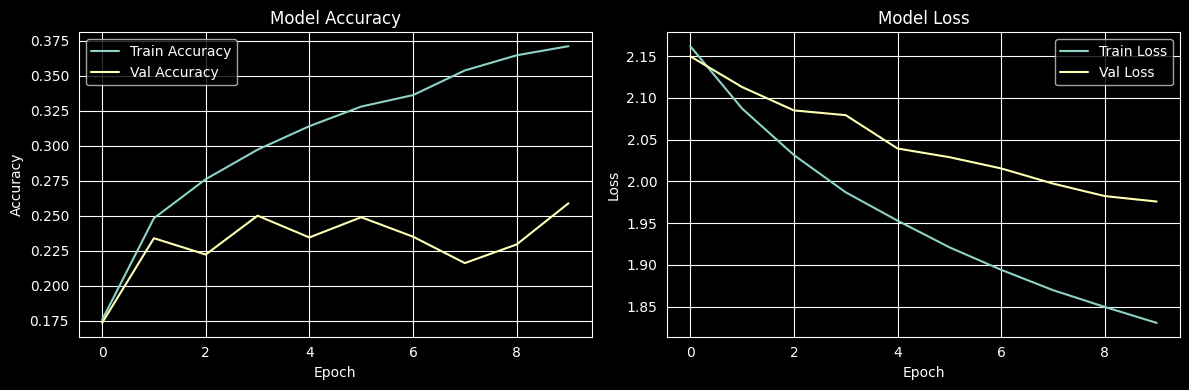

In [16]:
# Plot training history
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()